# More Multivariate Normal Things


## What is not Multivariate Regression

--- 

Rather than $\mathbf{y}_{n\times 1} \sim \mathcal{MVN}(\mathbf{X}_{n\times p}\boldsymbol{\beta}_{p\times 1}, \Sigma_{n\times n} = \sigma^2I_{n\times n})$

- where we used a multivariate $\mathcal{MVN}(\underset{p \times 1}{\boldsymbol\beta_0}, \underset{p \times p}{\Sigma_\beta})$ prior fo  $\boldsymbol \beta_{p\times 1}$ 
- and a univariate prior for precision $\phi = \sigma^{-2}$ or variance $\sigma^2$ such as $\text{gamma}(a,b)$ or $\mathcal{IG}(a,b)$

what about $\underset{m\times 1}{\mathbf{y}_i} \overset{iid}{\sim} \mathcal{MVN}(\boldsymbol{\beta}_{m\times p}^\top \underset{p\times 1}{\mathbf{x}_i},  \Sigma_{m\times m} \neq \sigma^2I_{n\times n})$ which models

- $\underset{n\times m}{\mathbf{y}}$ with
    - $E[\underset{n\times p}{\mathbf{y}}| \underset{n\times m}{\mathbf{X}} ] = \underset{n\times p}{\mathbf{X}}\boldsymbol{\beta}_{p\times m}$
    - $COV[\underset{\text{both } m\times 1}{\mathbf{y}_i, \mathbf{y}_j}] = \Sigma_{m\times m} $


The **likelihood** is
   
$\begin{align*}
f(\underset{n\times m}{\mathbf{y}}|\underset{n\times p}{\mathbf{X}}, \boldsymbol{\beta}_{p\times m}, \Sigma_{m\times m})
& ={} \prod_{i=1}^n (2\pi )^{-m/2}\det(\Sigma_{m\times m})^{-1/2}\,\exp \left(-{\frac {1}{2}}(\underset{m\times 1}{\mathbf{y}_i} - \boldsymbol{\beta}_{m\times p}^\top \underset{p\times 1}{\mathbf{x}_i} )^\top \Sigma_{m\times m}^{-1}(\underset{m\times 1}{\mathbf{y}_i} - \boldsymbol{\beta}_{m\times p}^\top \underset{p\times 1}{\mathbf{x}_i} )\right)\\ 
& \propto{} \det({ {\Sigma }})^{-n/2}\,\exp \left(\sum_{i=1}^n -{\frac {1}{2}}(\underset{m\times 1}{\mathbf{y}_i} - \boldsymbol{\beta}_{m\times p}^\top \underset{p\times 1}{\mathbf{x}_i} )^\top\Sigma_{m\times m}^{-1}(\underset{m\times 1}{\mathbf{y}_i} - \boldsymbol{\beta}_{m\times p}^\top \underset{p\times 1}{\mathbf{x}_i} )\right)\\ 
& \quad\; \text{The trace of a square matrix is the sum of its diagonal elements}\\
& = \det({ {\Sigma }})^{-n/2}\,\exp \left(-\frac{1}{2} \text{trace}\big((\underset{n\times m}{\mathbf{y}} - \underset{n\times p}{\mathbf{X}}\boldsymbol{\beta}_{p\times m}) \Sigma_{m\times m}^{-1} (\underset{n\times m}{\mathbf{y}} - \underset{n\times p}{\mathbf{X}}\boldsymbol{\beta}_{p\times m})^\top\big)\right)\\ 
& = \det({ {\Sigma }})^{-n/2}\,\exp \overset{\Large \text{trace}(ABC) \; = \;  \text{trace}(CAB)}{\left( -\frac{1}{2} \text{trace}\big((\underset{n\times m}{\mathbf{y}} - \underset{n\times p}{\mathbf{X}}\boldsymbol{\beta}_{p\times m})^\top(\underset{n\times m}{\mathbf{y}} - \underset{n\times p}{\mathbf{X}}\boldsymbol{\beta}_{p\times m}) \Sigma_{m\times m}^{-1} \big)\right)}\\ 
& = \det({\Sigma})^{-n/2}\,\exp \left( -\frac{1}{2} \text{trace}\big(\underset{\text{both } n\times m}{\boldsymbol \epsilon^\top \boldsymbol \epsilon} \underset{m\times m}{\Sigma^{-1}}\big)\right)\\ 
& = \det({\Sigma})^{-n/2}\,\exp \left( -\frac{1}{2} \text{trace}\big( \tilde{\underset{m\times m}{\boldsymbol \Psi}} \underset{m\times m}{\Sigma^{-1}}\big) \right)\\ 
& \propto {}
\mathcal{W}^{-1}\left({\mathbf\Psi} = \tilde{\underset{m\times m}{\boldsymbol \Psi}}, \nu = n-m-1 \right) 
\end{align*}$

an [Inverse-Wishart](https://en.wikipedia.org/wiki/Inverse-Wishart_distribution) distribution when viewed as a function of $\Sigma$.


## Inverse-Wishart Distributions

---

Thus for an **inverse Wishart** $\mathcal{W}^{-1}\left({\mathbf\Psi} = \underset{m\times m}{\boldsymbol \Psi_0}, \nu = n_0+m+1 \right)$ 
 prior for covariance $\Sigma_{m\times m}$ the **full conditional**

$\begin{align*}
f(\Sigma_{m\times m} | \underset{n\times m}{\mathbf{y}},\underset{n\times p}{\mathbf{X}}, \boldsymbol{\beta}_{p\times m}) &\propto{}
f(\underset{n\times m}{\mathbf{y}}|\underset{n\times p}{\mathbf{X}}, \boldsymbol{\beta}_{p\times m}, \Sigma_{m\times m}) \times p(\Sigma)\\
&\propto{} 
\det({\Sigma})^{-n/2}\,\exp \left( -\frac{1}{2} \text{trace}\big( \tilde{\underset{m\times m}{\boldsymbol \Psi}} \underset{m\times m}{\Sigma^{-1}}\big) \right) \times 
\det({\Sigma})^{-(n_0+m+1)/2}\,\exp \left( -\frac{1}{2} \text{trace}\big( {\underset{m\times m}{\boldsymbol \Psi_0}} \underset{m\times m}{\Sigma^{-1}}\big) \right)\\
&\propto{} 
\det({\Sigma})^{-(n+n_0+m+1)/2}\,\exp \left( -\frac{1}{2} \text{trace}\big( \tilde{\underset{m\times m}{\boldsymbol \Psi}} \underset{m\times m}{\Sigma^{-1}}\big) -\frac{1}{2} \text{trace}\big( {\underset{m\times m}{\boldsymbol \Psi_0}} \underset{m\times m}{\Sigma^{-1}}\big) \right)\\
&\propto{} 
\det({\Sigma})^{-(n+n_0+m+1)/2}\,\exp \left( -\frac{1}{2} \text{trace}\Big( \big( \tilde{\underset{m\times m}{\boldsymbol \Psi}} + {\underset{m\times m}{\boldsymbol \Psi_0}} \big) \underset{m\times m}{\Sigma^{-1}} \Big) \right) 
\end{align*}$

is also seen to be an **inverse Wishart** $\mathcal{W}^{-1}\left({\mathbf\Psi} = \tilde{\underset{m\times m}{\boldsymbol \Psi}} + \underset{m\times m}{\boldsymbol \Psi_0}, \nu = n+n_0 \right)$ 

---

## Conditional MVN distributions (are MVN distributions) 

For **MVN** $f( \mathbf{\tilde x} = (\mathbf x,\mathbf x^*) )$ 

$$p\left(\mathbf{\tilde x}\;\Bigg|\;\boldsymbol \mu = \left[\begin{array}{c} \underset{q\times1}{\boldsymbol \mu_{\mathbf{ x}}}\\ \underset{r\times1}{\boldsymbol \mu_{\mathbf{ x^*}}} \end{array} \right], \boldsymbol \Sigma = \left[\begin{array}{cc}  \underset{q\times q}{{\boldsymbol {\Sigma }}_{\mathbf{x}}} &  \underset{q\times r}{{\boldsymbol {\Sigma }}_{\mathbf{x},\mathbf{x^*}}}\\  \underset{r \times q}{{\boldsymbol {\Sigma }}_{\mathbf{x^*}\!\!,\,\mathbf{x}} =  {\boldsymbol {\Sigma }}_{\mathbf{x},\mathbf{x^*}}^T} &  \underset{r\times r}{{\boldsymbol {\Sigma }}_{\mathbf{x*}}}\end{array}\right] \right) = {\frac {\exp \left(-{\frac {1}{2}}\left({\mathbf {\tilde x} }-{\boldsymbol {\mu }}\right)^{\mathrm {T} }{\boldsymbol {\Sigma }}^{-1}\left({\mathbf {\tilde x} }-{\boldsymbol {\mu }}\right)\right)}{\sqrt {(2\pi )^{q+r}|{\boldsymbol {\Sigma }}|}}}$$

the **conditional distribution** $f(\mathbf x^* | \mathbf x)$ of [is also **MVN**](https://en.wikipedia.org/wiki/Multivariate_normal_distribution#Conditional_distributions)
 
$$\mathbf{x^*} | \mathbf x, \boldsymbol \mu, \boldsymbol \Sigma \sim  \mathcal{MVN}\left( {\bar {\boldsymbol {\mu }}}= \underset{q\times1}{{\boldsymbol {\mu }}_{\mathbf{x^*}}}+ \underset{q\times r}{{\boldsymbol {\Sigma }}_{\mathbf{x^*}\!\!,\,\mathbf{x}}}  \underset{r\times r}{{\boldsymbol {\Sigma}}^{-1}_{\mathbf{x}}} \underset{r\times1}{\left(\mathbf {x} -{\boldsymbol {\mu }}_{\mathbf{x}}\right)},  {\overline {\boldsymbol {\Sigma }}}= \underset{q\times q}{{\boldsymbol {\Sigma }}_{\mathbf{x^*}}}- \underset{q\times r}{{\boldsymbol {\Sigma }}_{\mathbf{x^*}\!\!,\,\mathbf{x}}}  \underset{r\times r}{{\boldsymbol {\Sigma }}_{\mathbf{x}}^{-1}} \underset{r\times q}{{\boldsymbol {\Sigma }}_{\mathbf{x},\mathbf{x^*}}}  \right)$$

though if ${\boldsymbol {\Sigma }}_{\mathbf{x^*}\!\!,\,\mathbf{x}} = \mathbf{0}_{m \times n}$ then $\mathbf{x^*}$ is independent of $\mathbf{x}$ 



## What is Multivariate Regression?

For

- $y_{ik}$ the $k^{th}$ element of observation vector $\textbf{y}_{i}$ 
- $\textbf{y}_{i,-k}$ the vector of all other elements
- $\Sigma_{k,-k}$ the $k^{th}$ row without $\sigma_k^2 = \Sigma_{kk}$ and $\Sigma_{-k,k}$ the same for columns
- $\Sigma_{-k,-k}$ the $\Sigma$ matrix without the $k^{th}$ row and column 
- $\boldsymbol \beta_k$ the vector corresponding to the $k^{th}$ row if $\boldsymbol \beta$
- $\boldsymbol \beta_{-k}$ the $\boldsymbol \beta$ without the $k^{th}$ row

$\begin{align*}
p(y_{ik}|\textbf{y}_{i,-k}, \text{etc.}) &={} \mathcal{N} (y_{ik}|\textbf{x}_i^\top \boldsymbol \beta_k + \Sigma_{k,-k}\Sigma_{-k,-k}^{-1} \left( \textbf{y}_{i,-k} - \boldsymbol \beta_{-k} \textbf{x}_i \right), \sigma^2_k - \Sigma_{k,-k}\Sigma_{-k,-k}^{-1}\Sigma_{-k,k})) \\
&={} \mathcal{N} (y_{ik}|\textbf{x}_i^\top \boldsymbol \beta_k + \left( \textbf{y}_{i,-k} - \boldsymbol \beta_{-k} \textbf{x}_i \right)^\top \Sigma_{-k,-k}^{-1}\Sigma_{-k,k}, \sigma^2_k - \Sigma_{k,-k}\Sigma_{-k,-k}^{-1}\Sigma_{-k,k}) 
\end{align*}$

Thus for $\underset{n\times 1}{\mathbf{y}_k}$ the $k^{th}$ column of $\underset{n\times m)}{\mathbf{y}}$ and $\underset{n\times (m-1)}{\mathbf{y}_{-k}}$ the matrix $\underset{n\times m}{\mathbf{y}}$ without its $k^{th}$ column 

$\begin{align*}
\prod_{i=1}^n p(y_{ik}|\textbf{y}_{i,-k}, \text{etc.}) &\propto{} \exp\left(-\frac{\big(\underset{n\times 1}{\mathbf{y}_k} - (\underset{n\times (m-1)}{\mathbf{y}_{-k} - \textbf{X} \boldsymbol \beta_{-k}} )\underset{n\times 1}{\Sigma_{-k,-k}^{-1}\Sigma_{-k,k}} - \underset{n\times 1}{\textbf{X} \boldsymbol \beta_k} \big)^{\top}\big(\underset{n\times 1}{\mathbf{y}_k} - (\underset{n\times (m-1)}{\mathbf{y}_{-k} - \textbf{X} \boldsymbol \beta_{-k}} )\underset{n\times 1}{\Sigma_{-k,-k}^{-1}\Sigma_{-k,k}} - \underset{n\times 1}{\textbf{X} \boldsymbol \beta_k} \big)}{2(\sigma^2_k - \Sigma_{k,-k}\Sigma_{-k,-k}^{-1}\Sigma_{-k,k})} \right) 
\end{align*}$

which is a **linear regression model** with an adjustment for the **residuals** of the other $k-1$ regression models based on the covariance structure of the outcomes $\Sigma$




While the outcomes are a little more complex than usual, when viewed as a function of the $k^{th}$ column $\underset{p\times 1}{\boldsymbol{\beta}_k}$ of $\boldsymbol{\beta}_{p\times m}$ this is just a **standard linear regression model**

Which suggests a multivariate $\mathcal{MVN}(\underset{p \times 1}{\boldsymbol\beta_0}, \underset{p \times p}{\Sigma_\beta})$ prior for each $\underset{p\times 1}{\boldsymbol{\beta}_k}$

$\begin{align*}
f(\boldsymbol{\beta}_{k} | \underset{n\times m}{\mathbf{y}}, \underset{n\times p}{\mathbf{X}}, \underset{n\times (m-1)}{\boldsymbol \beta_{-k}}, \Sigma_{m\times m}) 
& \propto{} \prod_{i=1}^n p(y_{ik}|\textbf{y}_{i,-k}, \text{etc.}) \times p(\boldsymbol{\beta}_{k}) \\
& \propto{} \exp \left( -\frac{1}{2} (\underset{n\times 1}{\mathbf{\tilde y}_k} - \underset{n\times p}{\mathbf{X}}\underset{p\times 1}{\boldsymbol{\beta}_k})^\top \tilde \sigma_{k}^{-2}(\underset{n\times 1}{\mathbf{\tilde  y}_k} - \underset{n\times p}{\mathbf{X}}\underset{p\times 1}{\boldsymbol{\beta}_k})\right) \times \exp \left(-{\frac {1}{2}}(\boldsymbol\beta - \boldsymbol\beta_0)^\top \Sigma_\beta^{-1}(\boldsymbol\beta - \boldsymbol\beta_0)\right) \\
& \propto{} \mathcal{MVN}\left( COV \times \big(\Sigma_\beta^{-1} \beta_0 + \sigma_{k}^{-2}\mathbf{X}^\top \mathbf{\tilde y}_k\big), COV = \big(\Sigma_\beta^{-1} + \tilde \sigma_{k}^{-2}\mathbf{X}^\top\mathbf{X}\big)^{-1}  \right)
\end{align*}$




## More on Inverse-Wishart Distributions


In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


In [39]:
p = 2  # dimension 
dimension = 2
# scale matrix
Psi = np.eye(dimension)  # 2x2 identity 
try:
    nu = 1.01 # nu must be greater than p-1
    # nu is the "degrees of freedom"
    stats.invwishart(df=nu, scale=Psi)
    
except ValueError as error:
    print(error)
    
print("|Sigma|^{nu+p+1} with nu =", nu," > p-1 =",p-1,"?")

Degrees of freedom must be greater than the dimension of scale matrix minus 1.
|Sigma|^{nu+p+1} with nu = 1.0  > p-1 = 1 ?



$$E[\boldsymbol \Sigma] = \frac{\boldsymbol\Psi}{\nu - p - 1} \text{ for } \boldsymbol \Sigma \sim \mathcal{W}^{-1}(\boldsymbol \Psi,\nu) \text{ is defined for } \nu>p+1$$


In [138]:
                       # df=p-1 obviously won't work...
denom = 1              # df=p+1 won't work...
myIWD = stats.invwishart(df=p+1+denom, scale=Psi*[1,denom][denom>0])
myIWD.rvs(size=10000).mean(axis=0)

array([[0.35418046, 0.04453551],
       [0.04453551, 0.38427556]])

## The LKJ (not Inverse-Wishart) prior

The **covariance matrix** $ \Sigma_{p \times p} = {D R D} = {D LL^\top D}$ for 
- ${D} = \operatorname{diag}(\boldsymbol \sigma)$ the diagonal matrix of **standard deviations** 
- ${R}$ the **correlation matrix** with all diagonal values equal to $1$
- ${L}$ the lower diagonal of the **Cholesky decomposition** of ${R}$

The **LKJ (Lewandowski-Kurowicka-Joe) prior** is [simpler to evaluate](https://mc-stan.org/docs/functions-reference/cholesky-lkj-correlation-distribution.html)  than the **Inverse-Wishart** 

$$\require{cancel} 
\begin{align*}
p( {R}) &\propto {}\det({R})^{\eta -1}\\
f^{-1}( {L}) &={} {L} {L}^\top = R\\
p( {L}) &\propto{} \det({LL^\top})^{\eta -1} \det(J) = \underbrace{\left(\prod_{k=1}^p  {L}_{kk}\right)^{\eta -1}}_{\det({L})^{\eta -1}}\underbrace{\left(\prod_{k=1}^p  {L}_{kk}^\top\right)^{\eta -1}}_{\det({L^\top})^{\eta -1}} \underbrace{\left(\prod_{k=1}^p 2 {L}_{kk}^{p+1-k}\right)}_{\det(J)} = 2 \prod_{k=1}^p  {L}_{kk}^{p+1-k + 2(\eta-1)}\\
J &={} \frac{d f^{-1}( {L})}{d  {L}} \quad J_{ij} = \frac{d {r}_i}{d {l}_j}\\
\end{align*}$$

since (1) the determinant of a product is the product of the determinants, (2) the determinant of a triangular matrix is the product of the diagonals, and (3) the Jacobian matrix $J$ is also triangular as given below.



$\begin{align*}
LL^T &={}
\begin{array}{|c|c|c|}
\hline
l_1 = L_{11} & & \\\hline
l_2 = L_{21} & l_4 = L_{22} &\\\hline
l_3 = L_{31} & l_5 = L_{32} & l_6 = L_{33} \\\hline
\end{array} \times 
\begin{array}{|c|c|c|}
\hline
L_{11} & L_{21} & L_{31} \\\hline
 & L_{22} &  L_{32} \\\hline
 & & L_{33} \\\hline
\end{array}\\
&={}
\begin{array}{|l|l|l|}
\hline
r_1 = R_{11} = L_{11}^2 & r_2 & r_3 \\\hline
r_2 = R_{12} = L_{21}L_{11} & r_4 = R_{22} = L_{12}^2 + L_{22}^2 & r_5\\\hline
r_3 = R_{13} = L_{31}L_{11} & r_5 = R_{32} = L_{31}L_{21} + L_{32}L_{22} & r_6 = L_{31}^2 + L_{32}^2 + L_{33}^2 \\\hline
\end{array}\\
J &={}
\begin{array}{|l|l|l|l|l|l|}
\hline
\frac{dr_1}{dl_1}=2L_{11}&\frac{dr_1}{dl_2}=0&\frac{dr_1}{dl_3}=0&\frac{dr_1}{dl_4}=0&\frac{dr_1}{dl_5}=0&\frac{dr_1}{dl_6}=0\\\hline
\frac{dr_2}{dl_1}&\frac{dr_2}{dl_2} = L_{11} &\frac{dr_2}{dl_3}=0&\frac{dr_2}{dl_4}=0&\frac{dr_2}{dl_5}=0&\frac{dr_2}{dl_6}=0\\\hline
\frac{dr_3}{dl_1}&\frac{dr_3}{dl_2}&\frac{dr_3}{dl_3} = L_{11} &\frac{dr_3}{dl_4}=0&\frac{dr_3}{dl_5}=0&\frac{dr_3}{dl_6}=0\\\hline
\frac{dr_4}{dl_1}&\frac{dr_4}{dl_2}&\frac{dr_4}{dl_3}&\frac{dr_4}{dl_4}=2L_{22}&\frac{dr_4}{dl_5}=0&\frac{dr_4}{dl_6}=0\\\hline
\frac{dr_5}{dl_1}&\frac{dr_5}{dl_2}&\frac{dr_5}{dl_3}&\frac{dr_5}{dl_4}&\frac{dr_5}{dl_5}=L_{22}&\frac{dr_5}{dl_6}=0\\\hline
\frac{dr_6}{dl_1}&\frac{dr_6}{dl_2}&\frac{dr_6}{dl_3}&\frac{dr_6}{dl_4}&\frac{dr_6}{dl_5}&\frac{dr_6}{dl_6}=2L_{33}\\\hline
\end{array}
\end{align*}
$

### More details

$p(\mathbf {R}) \propto \det(\mathbf{R}_{p \times p})^{\eta -1}$ with $\eta=1$ is $p(\mathbf {R}) \propto 1$ which specifies a uniform distribution on **correlation matrices**. This is nonetheless a **proper prior** and so results in a **proper posterior** when used with the **multivariate regression** specification above.

> $p(\boldsymbol \Sigma)\propto 1$ is an **improper prior** and so results in an **improper posterior** when used with the **multivariate regression** specification above until $n$ results in a sufficiently large $\nu$. 
>
> - Intuitively, the difference here is that each element of $\Sigma$ is unbounded while each element of $R$ is bounded.

The absolute **determinant** is the product of the **singular values**
- The **determinant** is positive for **positive definite matrices** such as $R$
- For **correlation matrices** the **determinant** is largest when all **singular values** (which sum to $p$) are equal to $1$ which happens when all off-diagonal correlations are $0$

Increasing $\eta \rightarrow \infty$ thus favors **correlation matrices** with 
smaller magnitudes of component correlations.

Univariate priors for $\sigma_k = \boldsymbol \sigma_k$ are needed to complete the full specification $p(\boldsymbol \Sigma) \propto p(\boldsymbol \sigma)p(\mathbf {R})$.

> This is the first time we leverage the proportionality starting immediately with the prior (before even considering the posterior). 








In [141]:
import pymc as pm 

with pm.Model() as LKJ:
    packed_L = pm.LKJCholeskyCov("packed_L", n=2, eta=2.0, 
                                 sd_dist=pm.Exponential.dist(1.0, shape=2), compute_corr=False)
packed_L.eval()    

array([1.49661758, 0.03112387, 0.13179168])

In [142]:
with LKJ:
    L = pm.expand_packed_triangular(2, packed_L)
    Sigma = L.dot(L.T)
Sigma.eval()#.shape

array([[2.23986417, 0.04658053],
       [0.04658053, 0.01833774]])

In [ ]:
L.eval()

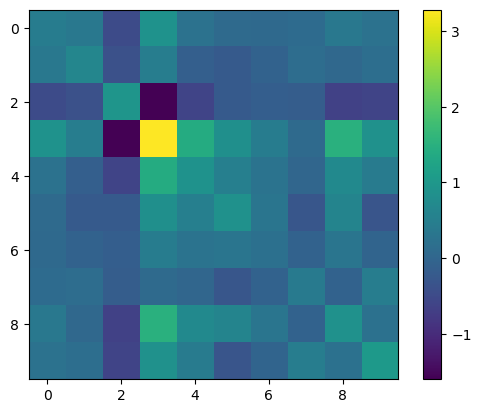

In [217]:
p=10
Psi=np.eye(p)
a_cov = stats.invwishart(df=p+2, scale=Psi).rvs()
n=100
x=stats.multivariate_normal(mean=np.zeros(p), cov=a_cov).rvs(size=n)
plt.imshow(a_cov)
plt.colorbar();

In [218]:
with pm.Model() as MNV_LKJ:
    
    packed_L = pm.LKJCholeskyCov("packed_L", n=p, eta=2.0, 
                                 sd_dist=pm.Exponential.dist(1.0, shape=2), 
                                 compute_corr=False)
    L = pm.expand_packed_triangular(p, packed_L)
    Sigma = pm.Deterministic('Sigma', L.dot(L.T))
    mu = pm.MvNormal('mu', mu=0, cov=np.eye(p), shape=p) 
    y = pm.MvNormal('y', mu=mu, chol=L,  #cov=Sigma
                    shape=(n,1), observed=x)   
    
    idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [packed_L, mu]


/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 28 seconds.


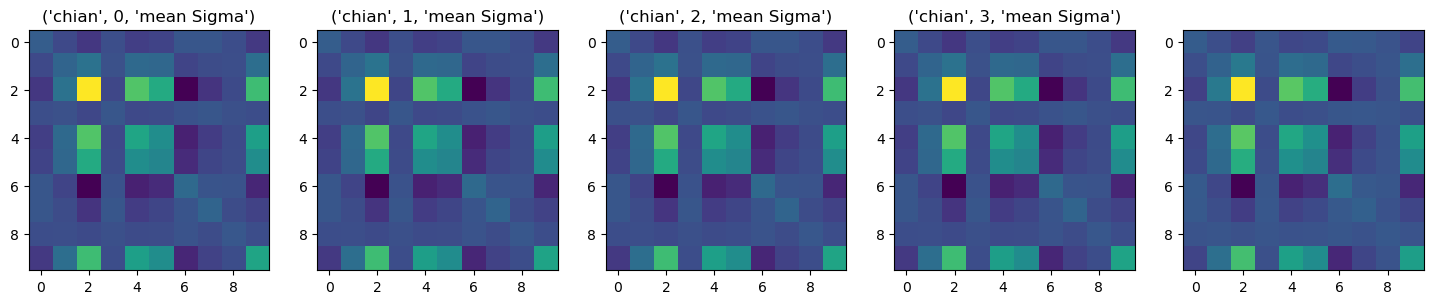

In [215]:
fig,ax = plt.subplots(1,5,figsize=(18,4))
ax[-1].imshow(a_cov)
ax[0].set_title(("Sigma used to generate y"))
for chain in range(4):
    ax[chain].imshow(idata.posterior['Sigma'].mean(axis=1)[chain])
    ax[chain].set_title(("chian",chain,"mean Sigma"))

## MVN computation 

Using the **Cholesky decomposition** is desirable because it provides efficient computation **MVN** evaluations $(2\pi )^{-k/2}\det({\boldsymbol {\Sigma }})^{-1/2}\,\exp \left(-{\frac {1}{2}}( {y} -{X\beta})^\top{\boldsymbol {\Sigma }}^{-1}({y} - {X\beta})\right)$ since

- $\det({\boldsymbol {\Sigma }}) = \det({LL^T}) = \det({L}) \det({L^T}) = \prod_{k=1}^p  {L}_{kk}^2$ 

as already seen above, but now also

- $(\textbf{y}-\boldsymbol\mu)^\top\boldsymbol\Sigma^{-1}(\textbf{y}-\boldsymbol\mu) = \boldsymbol \epsilon^\top  {L}^{-\top} {L}^{-1} \boldsymbol \epsilon = \underbrace{( {L}^{-1} \boldsymbol \epsilon)^\top( {L}^{-1} \boldsymbol \epsilon) =  \textbf{x}^\top \textbf{x}}_{\Large \Longrightarrow \; {L} \textbf{x}\; =\; \boldsymbol \epsilon} $ 

where $\textbf{x}$ can be efficiently solved for based on **lower triangular backwards substitution** and hence $\textbf{x}^\top \textbf{x}$ directly computed without requiring the inversion $\Sigma^{-1}$


## Week 10 Homework

---

### Q1: perform Bayesian Logistic Regression 

- For a binary outcome dataset you find interesting (perhaps from kaggle.com?)
- Model the outcome as a bernoulli random variable and use a **logit link** function
- Use `pm.Normal('betas', mu=0, sigma=1, shape=p)` rather than the `pm.MvNormal` version
- Provide inference with Bayesian posterior analysis and report MCMC diagnostics



### Q1 Answer:

In [1]:
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
data = pd.read_csv('diabetes.csv')
print(data.head())

X = data.drop(columns = ["Outcome"]).values
y = data["Outcome"].values
n, p = X.shape

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_standardized = (X - X_mean) / X_std


with pm.Model() as LRM:
    betas = pm.Normal('betas', mu=0, sigma=1, shape=p)
    y_obs = pm.Bernoulli('y_obs', p = 1/(1+pm.math.exp(-X_standardized@betas)), observed = y)
    idata = pm.sample()

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


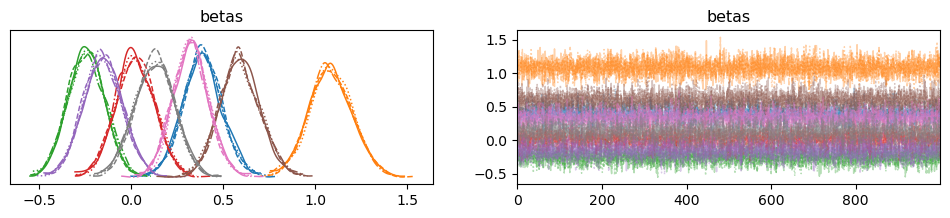

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]  0.387  0.105   0.186    0.585      0.002    0.001    4554.0   
betas[1]  1.085  0.116   0.863    1.305      0.002    0.001    5021.0   
betas[2] -0.243  0.099  -0.425   -0.056      0.001    0.001    5088.0   
betas[3]  0.023  0.105  -0.157    0.235      0.002    0.002    4514.0   
betas[4] -0.154  0.105  -0.357    0.039      0.001    0.001    5064.0   
betas[5]  0.591  0.109   0.396    0.809      0.002    0.001    4910.0   
betas[6]  0.325  0.096   0.149    0.509      0.001    0.001    5548.0   
betas[7]  0.128  0.106  -0.076    0.317      0.002    0.001    4303.0   

          ess_tail  r_hat  
betas[0]    3136.0    1.0  
betas[1]    3282.0    1.0  
betas[2]    3252.0    1.0  
betas[3]    3015.0    1.0  
betas[4]    3376.0    1.0  
betas[5]    3185.0    1.0  
betas[6]    3333.0    1.0  
betas[7]    3504.0    1.0  


In [22]:
# Posterior analysis
import arviz as az
az.plot_trace(idata)
plt.show()

# Summary statistics
summary = az.summary(idata)
print(summary)

For the posterior distributions, $\boldsymbol \beta$ has smooth unimodal posterior densities. All of its respective chains are similar to each other. This shows that the posterior distributions of $\boldsymbol \beta$ are stable.

For the time series, $\boldsymbol \beta$ fluctuate around stable means, suggesting the sampler has converged and is mixing well.

The mcse are fairly small for both values, which means the precision of the estimate is high.

The effective sample size is over 4000, which is larger than the sample size.

### Q2: perform Bayesian Multivariate Regression

- For a data set for which modeling multiple continuous outcomes might be interesting (perhaps from kaggle.com?)
- Use `pm.Normal('betas', mu=0, sigma=1, shape=(p,m))` rather than a `pm.MvNormal` alternative
- Use `y = pm.MvNormal('y', mu=X@betas, chol=L, observed=x)` for `(n,m)` shaped `y` and `(n,p)` shaped `X`
- Downsample your dataset to tentatively explore the effect of different values of `n`,`m`,`p` and 
    - report on your findings and based on that 
    - choose a "reasonably small" sized data set to perform an actual analysis
- Provide inference with Bayesian posterior analysis and report MCMC diagnostics



### Q2 Answer:

In [2]:
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

#### Downsample my dataset and reduce my number of predictors and outcomes. (reduce n,m,p)

In [3]:
data_d = pd.read_csv('measures_v2.csv').head(100)
print(data_d.head())

output_vars = ['stator_yoke', 'stator_tooth', 'stator_winding']
X_d = data_d.drop(columns = output_vars + ["profile_id", 'pm', 'u_q', 'coolant', 'u_d']).values
Y_d = data_d[output_vars].values
n_d, p_d = X_d.shape
m_d = Y_d.shape[1]
print(n_d,p_d,m_d)

        u_q    coolant  stator_winding       u_d  stator_tooth  motor_speed  \
0 -0.450682  18.805172       19.086670 -0.350055     18.293219     0.002866   
1 -0.325737  18.818571       19.092390 -0.305803     18.294807     0.000257   
2 -0.440864  18.828770       19.089380 -0.372503     18.294094     0.002355   
3 -0.327026  18.835567       19.083031 -0.316199     18.292542     0.006105   
4 -0.471150  18.857033       19.082525 -0.332272     18.291428     0.003133   

        i_d       i_q         pm  stator_yoke    ambient    torque  profile_id  
0  0.004419  0.000328  24.554214    18.316547  19.850691  0.187101          17  
1  0.000606 -0.000785  24.538078    18.314955  19.850672  0.245417          17  
2  0.001290  0.000386  24.544693    18.326307  19.850657  0.176615          17  
3  0.000026  0.002046  24.554018    18.330833  19.850647  0.238303          17  
4 -0.064317  0.037184  24.565397    18.326662  19.850639  0.208197          17  
100 5 3


In [4]:
X_d_mean = X_d.mean(axis=0)
X_d_std = X_d.std(axis=0)
X_d_standardized = (X_d - X_d_mean) / X_d_std

with pm.Model() as MNV:
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p_d,m_d))
    packed_L = pm.LKJCholeskyCov("packed_L", n=m_d, eta=2.0, 
                                 sd_dist=pm.Exponential.dist(1.0, shape=m_d), 
                                 compute_corr=False)
    L = pm.expand_packed_triangular(m_d, packed_L)
    Sigma = pm.Deterministic('Sigma', L.dot(L.T))
    y_obs = pm.MvNormal('y_obs', mu=X_d_standardized@betas, chol=L,  #cov=Sigma
                    observed=Y_d)
    idata_d = pm.sample()
  

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, packed_L]


/opt/conda/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
/opt/conda/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1513 seconds.


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

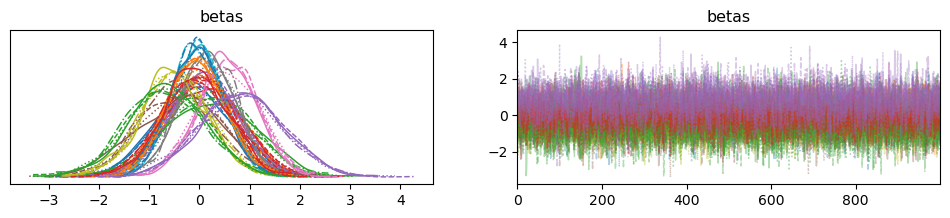

In [5]:
az.plot_trace(idata_d,var_names='betas')

In [7]:
summary_d = az.summary(idata_d)
print(summary_d)

                mean      sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Sigma[0, 0]  229.083  24.788  187.018  278.786      0.532    0.439    2223.0   
Sigma[0, 1]  236.125  25.533  189.613  283.848      0.549    0.453    2214.0   
Sigma[0, 2]  261.364  28.312  211.304  315.787      0.611    0.504    2203.0   
Sigma[1, 0]  236.125  25.533  189.613  283.848      0.549    0.453    2214.0   
Sigma[1, 1]  243.875  26.332  196.480  293.432      0.567    0.468    2205.0   
Sigma[1, 2]  270.458  29.230  218.883  326.601      0.632    0.520    2197.0   
Sigma[2, 0]  261.364  28.312  211.304  315.787      0.611    0.504    2203.0   
Sigma[2, 1]  270.458  29.230  218.883  326.601      0.632    0.520    2197.0   
Sigma[2, 2]  301.349  32.533  244.989  364.536      0.704    0.578    2189.0   
betas[0, 0]   -0.094   0.776   -1.508    1.358      0.011    0.012    4574.0   
betas[0, 1]    0.085   0.689   -1.148    1.435      0.010    0.010    4370.0   
betas[0, 2]    0.207   0.849   -1.427   

Downsampling can make the whole process less time consuming, but small sample size and less variables can make the estimated relationship between predictors and outcomes less accurate. 

I choose 1000 samples and the original predictors and outcomes to ensure the accuracy of the relationship between predictors and outcomes. 

In [38]:
data = pd.read_csv('measures_v2.csv').head(1000)
print(data.head())

output_vars = ['pm', 'stator_yoke', 'stator_tooth', 'stator_winding']
X = data.drop(columns = output_vars + ["profile_id"]).values
Y = data[output_vars].values
n, p = X.shape
m = Y.shape[1]
print(n,p,m)

        u_q    coolant  stator_winding       u_d  stator_tooth  motor_speed  \
0 -0.450682  18.805172       19.086670 -0.350055     18.293219     0.002866   
1 -0.325737  18.818571       19.092390 -0.305803     18.294807     0.000257   
2 -0.440864  18.828770       19.089380 -0.372503     18.294094     0.002355   
3 -0.327026  18.835567       19.083031 -0.316199     18.292542     0.006105   
4 -0.471150  18.857033       19.082525 -0.332272     18.291428     0.003133   

        i_d       i_q         pm  stator_yoke    ambient    torque  profile_id  
0  0.004419  0.000328  24.554214    18.316547  19.850691  0.187101          17  
1  0.000606 -0.000785  24.538078    18.314955  19.850672  0.245417          17  
2  0.001290  0.000386  24.544693    18.326307  19.850657  0.176615          17  
3  0.000026  0.002046  24.554018    18.330833  19.850647  0.238303          17  
4 -0.064317  0.037184  24.565397    18.326662  19.850639  0.208197          17  
1000 8 4


In [39]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_standardized = (X - X_mean) / X_std

with pm.Model() as MNV:
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p,m))
    packed_L = pm.LKJCholeskyCov("packed_L", n=m, eta=2.0, 
                                 sd_dist=pm.Exponential.dist(1.0, shape=m), 
                                 compute_corr=False)
    L = pm.expand_packed_triangular(m, packed_L)
    Sigma = pm.Deterministic('Sigma', L.dot(L.T))
    y_obs = pm.MvNormal('y_obs', mu=X_standardized@betas, chol=L,  #cov=Sigma
                    observed=Y)
    idata = pm.sample()
    

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, packed_L]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5985 seconds.


              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
betas[0, 0]  2.908  0.570   1.897    4.061      0.009    0.007    3682.0   
betas[0, 1]  2.751  0.401   1.988    3.493      0.007    0.005    3275.0   
betas[0, 2] -0.633  0.487  -1.519    0.276      0.009    0.006    3277.0   
betas[0, 3] -2.716  0.639  -3.905   -1.544      0.011    0.008    3562.0   
betas[1, 0] -0.469  0.444  -1.330    0.329      0.008    0.006    2809.0   
betas[1, 1]  0.122  0.342  -0.516    0.759      0.006    0.005    2803.0   
betas[1, 2]  0.501  0.454  -0.350    1.342      0.009    0.006    2755.0   
betas[1, 3]  1.013  0.578  -0.020    2.122      0.011    0.008    2776.0   
betas[2, 0]  4.302  0.736   2.942    5.693      0.010    0.007    5713.0   
betas[2, 1]  3.794  0.531   2.837    4.791      0.007    0.005    5114.0   
betas[2, 2] -2.104  0.595  -3.240   -1.007      0.008    0.006    4933.0   
betas[2, 3] -5.146  0.777  -6.519   -3.611      0.010    0.008    5547.0   
betas[3, 0] 

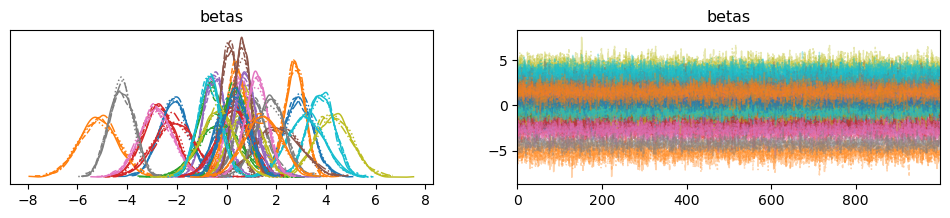

In [40]:
az.plot_trace(idata,var_names='betas')
summary = az.summary(idata,var_names='betas')
print(summary)

For the posterior distributions, $\boldsymbol \beta$ has smooth unimodal posterior densities. All of its respective chains are similar to each other. This shows that the posterior distributions of $\boldsymbol \beta$ are stable.

For the time series, $\boldsymbol \beta$ fluctuate around stable means, suggesting the sampler has converged and is mixing well.

The mcse are fairly small for both values, which means the precision of the estimate is high.

Most of the effective sample sizes are over 4000, which are larger than the sample size.

### Examples

In [295]:
n,m,p = 100,10,5
beta_ = np.ones((p,m))
X = stats.norm().rvs((n,p))
a_cov = stats.invwishart(df=m+2, scale=np.eye(m)).rvs()
x = X@beta_ + stats.multivariate_normal(mean=np.zeros(m), cov=a_cov).rvs(size=n)

with pm.Model() as MNV_LKJ:
    
    packed_L = pm.LKJCholeskyCov("packed_L", n=m, eta=2.0, 
                                 sd_dist=pm.Exponential.dist(1.0, shape=m), 
                                 compute_corr=False)
    L = pm.expand_packed_triangular(m, packed_L)
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p,m))
    Sigma = pm.Deterministic('Sigma', L.dot(L.T))
    y = pm.MvNormal('y', mu=X@betas, chol=L,  #cov=Sigma
                    observed=x)   
    
    idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [packed_L, betas]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.


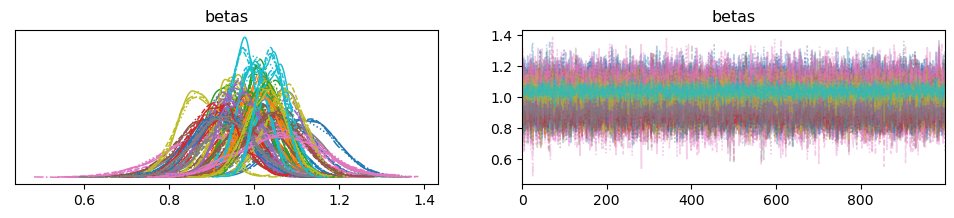

In [296]:
import arviz as az

az.plot_trace(idata,var_names='betas');

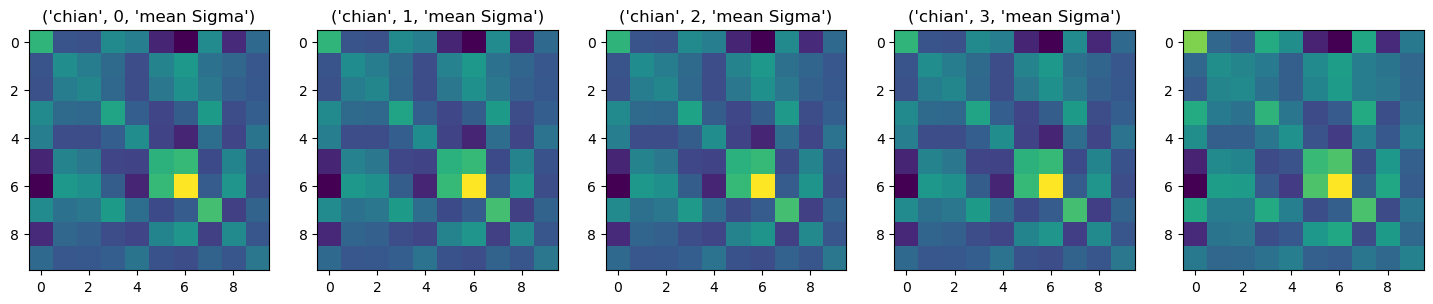

In [297]:
fig,ax = plt.subplots(1,5,figsize=(18,4))
ax[-1].imshow(a_cov)
ax[0].set_title(("Sigma used to generate y"))
for chain in range(4):
    ax[chain].imshow(idata.posterior['Sigma'].mean(axis=1)[chain])
    ax[chain].set_title(("chian",chain,"mean Sigma"))

### Probit Regression (as opposed to Logistic Regression)

- $\Phi$ is CDF of standard normal (and is also call the **inverse probit** function)
    - The **probit** function is $\Phi^{-1}$
- $z_i \sim N(x_i^\top\beta,1)$


$$\int \Phi(z_i)^{y_i} (1-\Phi(z_i))^{1-y_i}d\Phi(z) = \Phi(x_i^\top\beta)^{y_i} (1-\Phi(x_i^\top\beta))^{1-y_i} = p_i^{y_i} (1-p_i)^{1-y_i} $$

In [428]:
n,p=100,10
X,y=np.zeros((n,p)), np.random.choice([0,1],size=n)

with pm.Model() as GLM:
    betas = pm.Normal('betas', mu=0, sigma=1, shape=p)
    z = pm.Normal('z', mu=X@betas, sigma=1)
    # Pr(z>0) is pm.math.invprobit(X@betas)
    # E[z] is X@betas
    y = pm.Bernoulli('y', p=pm.math.invprobit(X@betas), observed=y)
    
with GLM:
    idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [429]:
n,p=100,10
X,y=np.zeros((n,p)), np.random.choice([0,1],size=n)

with pm.Model() as GLM:
    betas = pm.Normal('betas', mu=0, sigma=1, shape=p)
    z = pm.Normal('z', mu=X@betas, sigma=1)
    y = pm.Bernoulli('y', p=pm.math.invprobit(z), observed=y)
    
with GLM:
    idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


### Q3: perform Bayesian Multivariate Classification

- For a data set for which modeling multiple binary outcomes might be interesting (perhaps from kaggle.com?)
- Use `pm.Normal('betas', mu=0, sigma=1, shape=(p,m))` rather than a `pm.MvNormal` alternative
- Use `y = pm.Bernoulli('y', p=pm.math.invprobit(X@betas), observed=x)` for `(n,m)` shaped `y` and `(n,p)` shaped `X`
- Use latent `z = pm.MvNormal('z', mu=X@betas, chol=L)` as discussed in the "Generalized Linear Models (GLM)" section of the previous weeks lecture notes

> This provides normally distributed latent variables connected to the observed binary outcomes on which a latent covariance dependency structure may be modelled and estimated on the basis of imputing the unobserved latent variables based on their connection with the observed binary outcome variables.

- Downsample your dataset to tentatively explore the effect of different values of `n`,`m`,`p` and 
    - report on your findings and based on that 
    - choose a "reasonably small" sized data set to perform an actual analysis
- Provide inference with Bayesian posterior analysis and report MCMC diagnostics


### Q3 Answer:

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az

#### Downsample my dataset and reduce my number of predictors and outcomes. (reduce n,m,p)

In [4]:
data_d = pd.read_csv('diabetes.csv').head(100)
# print(data.head())

data_d['high_BMI'] = (data_d['BMI'] > 30).astype('int') 
data_d['high_glucose'] = (data_d['Glucose']).astype('int')
data_d['high_glucose'] = (data_d['high_glucose'] > 140).astype('int')
print(data_d.head())

X_d = data_d.drop(columns = ["Outcome", 'high_BMI', 'high_glucose', 
                             "BMI", "Glucose", "Insulin", "SkinThickness"]).values
Y_d = data_d[["Outcome", 'high_glucose']].values

n_d, p_d = X_d.shape
m_d = Y_d.shape[1]
print(n_d,p_d,m_d)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  high_BMI  high_glucose  
0                     0.627   50        1         1             1  
1                     0.351   31        0         0             0  
2                     0.672   32        1         0             1  
3                     0.167   21        0         0             0  
4                     2.288   33        1         1             0  
100 4 2


In [5]:
X_d_mean = X_d.mean(axis = 0)
X_d_std = X_d.std(axis = 0)
X_d_std = (X_d - X_d_mean) / X_d_std
X_d_standardized = (X_d - X_d_mean) / X_d_std

with pm.Model() as MVN_GLM:
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p_d,m_d))
    L,R,std = pm.LKJCholeskyCov("R", n=m_d, eta=2.0, 
                                sd_dist=pm.Exponential.dist(1.0, shape=m_d), 
                                compute_corr=True)
    z = pm.MvNormal('z', mu=X_d_standardized@betas, cov=R)
    y_obs = pm.Bernoulli('y_obs', p=pm.math.invprobit(X_d_standardized@betas), observed=Y_d)
    
    idata_d = pm.sample()
 

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, R, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6703 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 713 divergences after tuning. Increase `target_accept` or reparameterize.


/opt/conda/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/conda/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
R[0]          1.007  0.916   0.001    2.614      0.016    0.026    1230.0   
R[1]          0.003  0.493  -1.070    0.875      0.034    0.035     173.0   
R[2]          0.791  0.865   0.012    2.366      0.117    0.025      13.0   
R_corr[0, 0]  1.000  0.000   1.000    1.000      0.000      NaN    4000.0   
R_corr[0, 1]  0.050  0.447  -0.656    0.808      0.110    0.044      14.0   
...             ...    ...     ...      ...        ...      ...       ...   
z[97, 1]     -0.649  0.942  -2.421    1.156      0.028    0.018    1090.0   
z[98, 0]     -0.344  0.961  -2.113    1.481      0.021    0.050    2094.0   
z[98, 1]     -0.803  0.997  -2.679    1.167      0.067    0.021     203.0   
z[99, 0]     -0.503  1.115  -2.548    1.362      0.255    0.091      20.0   
z[99, 1]     -0.795  1.052  -2.586    1.140      0.104    0.026     110.0   

              ess_tail  r_hat  
R[0]            1516.0   1.02  
R[1]       

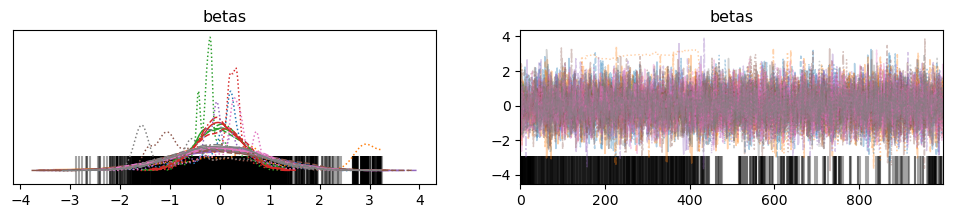

In [6]:
az.plot_trace(idata_d,var_names='betas')
summary = az.summary(idata_d)
print(summary)

When I reduce the sample size and number of predictors, the outcome becomes very unstable and we can see from the above both $\hat{r}$ and effective sample size are unstable. Those, to maintain stability, we choose not to reduce the sample size and number of predictors.  

In [57]:
data = pd.read_csv('diabetes.csv')
# print(data.head())

data['high_BMI'] = (data['BMI'] > 30).astype('int') 
data['high_glucose'] = (data['Glucose']).astype('int')
data['high_glucose'] = (data['high_glucose'] > 140).astype('int')
print(data.head())

X = data.drop(columns = ["Outcome", 'high_BMI', 'high_glucose', "BMI", "Glucose", "Insulin"]).values
Y = data[["Outcome", 'high_BMI', 'high_glucose']].values

n, p = X.shape
m = Y.shape[1]
print(n,p,m)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  high_BMI  high_glucose  
0                     0.627   50        1         1             1  
1                     0.351   31        0         0             0  
2                     0.672   32        1         0             1  
3                     0.167   21        0         0             0  
4                     2.288   33        1         1             0  
768 5 3


The following sampler uses a Bernoulli distribution with probability p determined by latent variable z for the posterior distribution of y. This may causes the outcome samples vary a lot. 

In [58]:
X_mean = X.mean(axis = 0)
X_std = X.std(axis = 0)
X_std = (X - X_mean) / X_std
X_standardized = (X - X_mean) / X_std

with pm.Model() as MVN_GLM:
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p,m))
    L,R,std = pm.LKJCholeskyCov("R", n=m, eta=2.0, 
                                sd_dist=pm.Exponential.dist(1.0, shape=m), 
                                compute_corr=True)
    z = pm.MvNormal('z', mu=X_standardized@betas, cov=R)
    y_obs = pm.Bernoulli('y_obs', p=pm.math.invprobit(z), observed=Y)
    
    idata = pm.sample()
    

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, R, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10507 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 1010 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
betas[0, 0] -0.067  1.122  -2.511    1.763      0.398    0.293       9.0   
betas[0, 1]  0.274  0.928  -1.353    2.101      0.275    0.199      13.0   
betas[0, 2] -0.416  1.444  -2.510    1.566      0.651    0.519       6.0   
betas[1, 0]  0.156  0.536  -1.067    1.117      0.114    0.089      18.0   
betas[1, 1]  0.409  0.712  -1.109    1.550      0.284    0.211       7.0   
betas[1, 2] -0.220  0.829  -1.343    1.025      0.330    0.245       8.0   
betas[2, 0] -0.140  0.604  -1.534    0.984      0.117    0.086      19.0   
betas[2, 1] -0.575  1.000  -2.336    1.114      0.416    0.310       6.0   
betas[2, 2]  0.101  0.838  -1.453    1.062      0.297    0.218       8.0   
betas[3, 0] -0.455  1.156  -2.016    1.313      0.481    0.371       6.0   
betas[3, 1] -0.196  1.049  -1.622    1.913      0.337    0.246      11.0   
betas[3, 2]  0.090  0.725  -1.426    1.439      0.112    0.108      36.0   
betas[4, 0] 

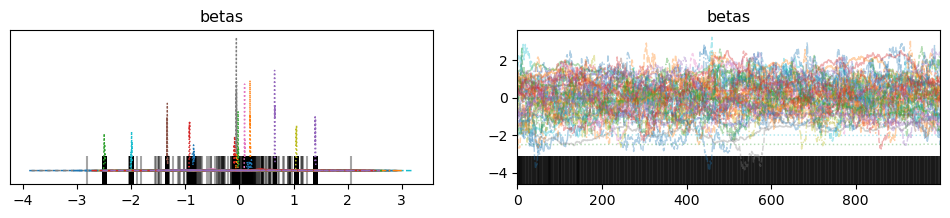

In [59]:
az.plot_trace(idata,var_names='betas')
summary = az.summary(idata,var_names='betas')
print(summary)

As shown from the plots, we cannot identify a specific distribution for each $\beta$. This may be because of our design of sampler. We also see all $\hat{r}$s are much higher than 1 and the effective sample sizes are small. These suggest this sampler has a bad performance. 

The following sampler will use a Bernoulli distribution with probability p only determined by $ X^T \boldsymbol \beta$. This is because $E[y|\textbf{x}_i] = p_i = \Phi(\textbf{x}_i^T \boldsymbol \beta) = Pr(z_i \geq 0) \; \textrm{ for } \; z_i \sim \mathcal N(\textbf{x}_i^T \boldsymbol \beta,1)$

In [60]:
with pm.Model() as MVN_GLM:
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p,m))
    L,R,std = pm.LKJCholeskyCov("R", n=m, eta=2.0, 
                                sd_dist=pm.Exponential.dist(1.0, shape=m), 
                                compute_corr=True)
    z = pm.MvNormal('z', mu=X_standardized@betas, cov=R)
    y_obs = pm.Bernoulli('y_obs', p=pm.math.invprobit(X_standardized@betas), observed=Y)
    
    idata = pm.sample()
 

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, R, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16858 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 90 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
betas[0, 0] -0.018  0.966  -1.832    1.828      0.042    0.030     532.0   
betas[0, 1] -0.081  0.954  -1.827    1.719      0.059    0.042     263.0   
betas[0, 2] -0.063  1.003  -1.769    1.937      0.061    0.043     273.0   
betas[1, 0] -0.086  0.663  -1.334    1.109      0.035    0.025     352.0   
betas[1, 1]  0.019  0.702  -1.280    1.289      0.039    0.028     319.0   
betas[1, 2] -0.034  0.726  -1.362    1.348      0.072    0.051     101.0   
betas[2, 0]  0.052  0.789  -1.512    1.438      0.044    0.031     327.0   
betas[2, 1] -0.010  0.794  -1.425    1.581      0.042    0.029     367.0   
betas[2, 2] -0.012  0.835  -1.586    1.460      0.056    0.040     219.0   
betas[3, 0]  0.123  1.002  -1.810    1.937      0.056    0.040     314.0   
betas[3, 1] -0.057  0.975  -1.928    1.717      0.055    0.039     310.0   
betas[3, 2]  0.086  1.015  -1.920    1.824      0.048    0.034     442.0   
betas[4, 0] 

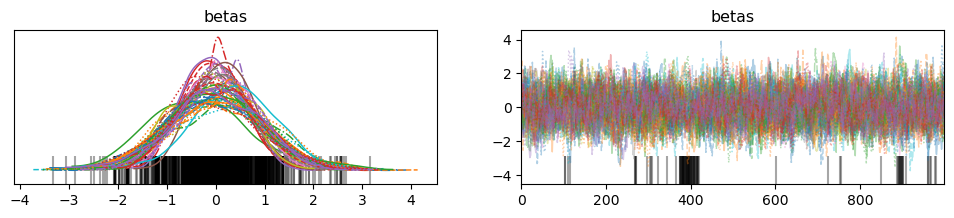

In [61]:
az.plot_trace(idata,var_names='betas')
summary = az.summary(idata,var_names='betas')
print(summary)

This sampler do have a few $\beta$s with $\hat{r}$ larger than 1 and the effective sample sizes are smaller than the sample sizes (4000). But from the plots, the results are relatively stable and the distributions of $\boldsymbol \beta$ can be obviously recognized as Normal distributions. 

### Examples

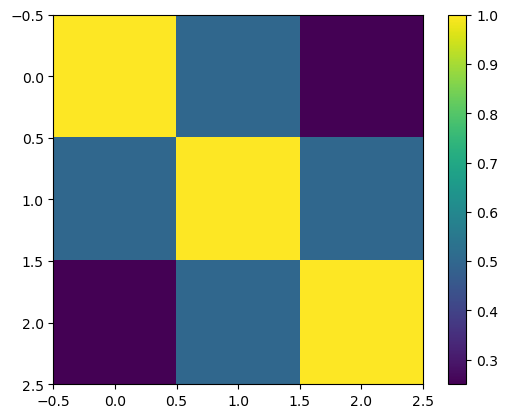

In [393]:
n,m,p = 100,3,3
beta_ = np.ones((p,m))
X = stats.norm().rvs((n,p))
#a_cov = stats.invwishart(df=m+2, scale=np.ones(m)).rvs()
a_cor = (np.ones((p,p))+np.diag((1,1,1)))/2
a_cor[0,-1] = 0.25
a_cor[-1,0] = 0.25
x = X@beta_ + stats.multivariate_normal(mean=np.zeros(m), cov=a_cor).rvs(size=n)
plt.imshow(a_cor)
plt.colorbar()

# Make outcome binary
x = x>0

In [394]:
with pm.Model() as GLM:
    
    L,R,std = pm.LKJCholeskyCov("R", n=m, eta=2.0, 
                                sd_dist=pm.Exponential.dist(1.0, shape=m), 
                                compute_corr=True)
    #L = pm.expand_packed_triangular(m, packed_L)
    betas = pm.Normal('betas', mu=0, sigma=1, shape=(p,m))
    #Sigma = pm.Deterministic('Sigma', L.dot(L.T))
    z = pm.MvNormal('z', mu=X@betas, cov=R) #cov=Sigma
    # the probit is the inverse cdf of a standard normal
    # the inverse probit is the cdf of a standard normal
    y = pm.Bernoulli('y', p=pm.math.invprobit(z), observed=x)   
    # Integrating out z would give:
    #y = pm.Bernoulli('y', p=pm.math.invprobit(X@betas), observed=x)   
    
    idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [R, betas, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 141 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 1424 divergences after tuning. Increase `target_accept` or reparameterize.


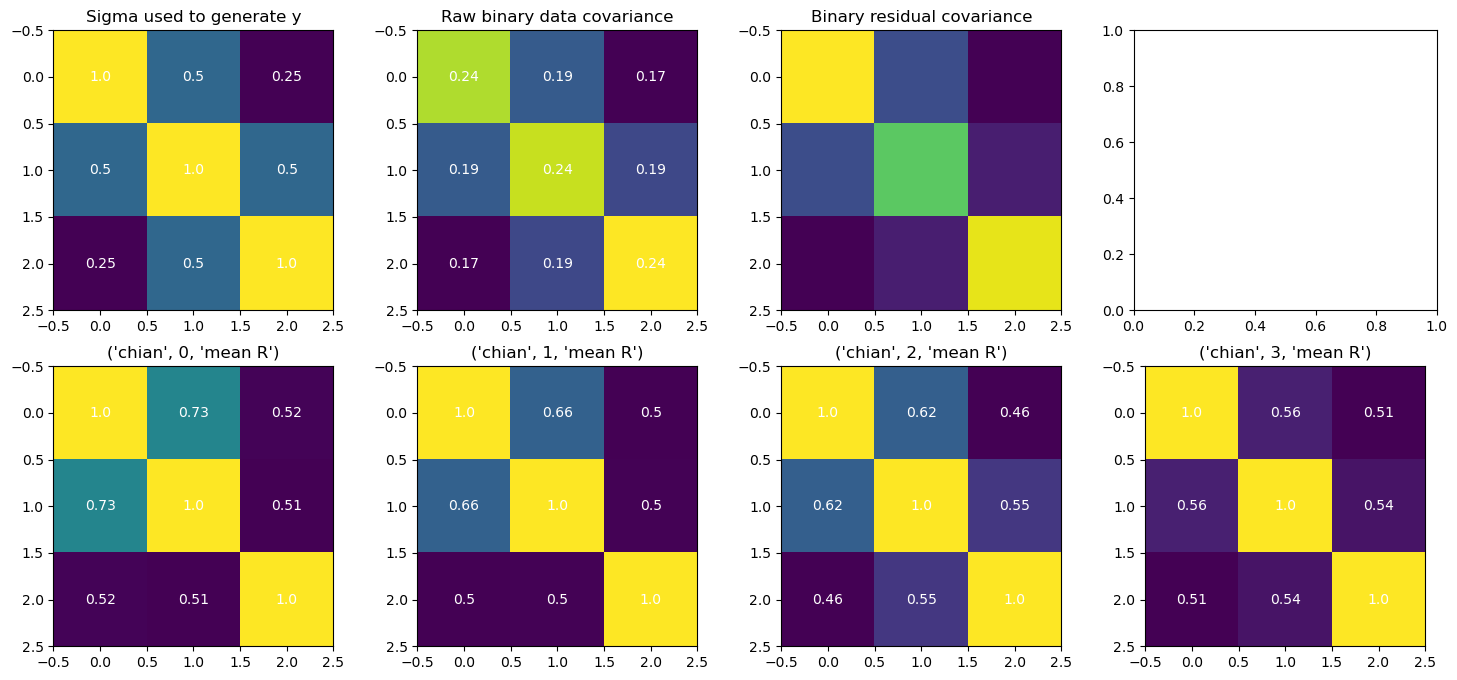

In [427]:
fig,ax = plt.subplots(2,4,figsize=(18,8))
ax[0,0].imshow(a_cor)
ax[0,0].set_title(("Sigma used to generate y"))
for i in range(3):
    for j in range(3):
        ax[0,0].text(i,j,str(round(a_cor[j,i],2)),
                     c='w', ha='center', va='center')
ax[0,1].imshow(np.cov(x.T))
ax[0,1].set_title(("Raw binary data covariance"))
for i in range(3):
    for j in range(3):
        ax[0,1].text(i,j,str(round(np.cov(x.T)[j,i],2)),
                     c='w', ha='center', va='center')
ax[0,2].imshow(np.cov((x-stats.norm().cdf(X@beta_)).T))
ax[0,2].set_title(("Binary residual covariance"))
for chain in range(4):
    ax[1,chain].imshow(idata.posterior['R_corr'].mean(axis=1)[chain])
    for i in range(3):
        for j in range(3):
            ax[1,chain].text(i,j,str(round(idata.posterior['R_corr'].mean(axis=1)[chain].values[j,i],2)),
                             c='w', ha='center', va='center')
    ax[1,chain].set_title(("chian",chain,"mean R"))

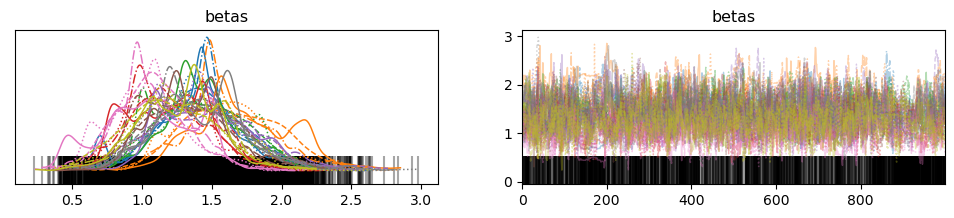

In [405]:
az.plot_trace(idata,var_names='betas');